In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#loading the dataset
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_item.csv")
payments = pd.read_csv("payments.csv")
reviews = pd.read_csv("reviews.csv")
products = pd.read_csv("products.csv")
sellers = pd.read_csv("sellers.csv")
category = pd.read_csv("category_translation.csv")
location = pd.read_csv("location.csv")


# verifying whether I can able to retrieve the data
customers.head()
orders.head()

#checking dataset size
customers.shape
orders.shape

#checking column names
customers.columns
orders.columns

#getting to know about the dataser structure
customers.info()


#summarizing statistics
customers.describe()


orders.info()


#checking for missing values 

customers.isnull().sum()
orders.isnull().sum()

orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

datasets = {
    "customers" : customers,
    "orders" : orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category" : category,
    "location" : location
}
print("Checking for duplicates")
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()}")

for name, df in datasets.items():
    print("\n", "="*40)
    print(name.upper())
    print(df.isnull().sum())

for name, df in datasets.items():
    print("\n", "="*40)
    print(name.upper())
    print(df.dtypes)


print(customers["customer_id"].duplicated().sum())
print(orders["order_id"].duplicated().sum())
print(products["product_id"].duplicated().sum())
print(sellers["seller_id"].duplicated().sum())

    

    








<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [71]:
#Data integration

master_df = orders.copy()

master_df = master_df.merge(
    customers,
    on ="customer_id",
    how = "left"
)

print(master_df.shape)

master_df.head()

(99441, 12)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [72]:
#second merge

master_df = master_df.merge(
    order_items,
    on ="order_id",
    how= "left"
)

print(master_df.shape)
master_df.head()

(113425, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [73]:
# third merge

master_df = master_df.merge(
    products,
    on = "product_id",
    how = "left"
    
)

print(master_df.shape)

master_df.head()


(113425, 26)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [74]:
master_df = master_df.merge(
    payments,
    on = "order_id",
    how = "left"
)

print(master_df.shape)

master_df.head()

master_df.columns

(118434, 30)


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value'],
      dtype='object')

In [75]:
master_df = master_df.merge(
    reviews,
    on= "order_id",
    how= "left"
)

print(master_df.shape)

(119143, 36)


In [77]:
master_df = master_df.merge(
    category,
    on = "product_category_name",
    how = "left"
)

print(master_df.shape)

(119143, 37)


In [78]:
master_df = master_df.merge(
    sellers,
    on = "seller_id",
    how = "left"
)

print(master_df.shape)

(119143, 40)


In [79]:
reviews["order_id"].duplicated().sum()

np.int64(551)

In [80]:
#total revenue
master_df["price"].sum()

np.float64(14273699.650000002)

In [81]:
#how many customers done shopping from us
master_df["customer_unique_id"].nunique()


96096

In [82]:
master_df.groupby("customer_unique_id")["price"].sum()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2     129.90
0000b849f77a49e4a4ce2b2a4ca5be3f      18.90
0000f46a3911fa3c0805444483337064      69.00
0000f6ccb0745a6a4b88665a16c9f078      25.99
0004aac84e0df4da2b147fca70cf8255     180.00
                                     ...   
fffcf5a5ff07b0908bd4e2dbc735a684    1570.00
fffea47cd6d3cc0a88bd621562a9d061      64.89
ffff371b4d645b6ecea244b27531430a      89.90
ffff5962728ec6157033ef9805bacc48     115.00
ffffd2657e2aad2907e67c3e9daecbeb      56.99
Name: price, Length: 96096, dtype: float64

In [83]:
state_revenue = (
    master_df.groupby("customer_state")["price"].sum().sort_values(ascending = False)
)

print(state_revenue)

customer_state
SP    5477008.74
RJ    1921752.53
MG    1645847.27
RS     791716.84
PR     708794.22
BA     543243.99
SC     539896.20
DF     315122.29
GO     313198.27
ES     284771.30
PE     272271.97
CE     240095.13
PA     184889.93
MT     171109.74
PB     123816.24
MA     123077.67
MS     121358.47
RN      94607.86
PI      92227.70
AL      83314.32
SE      60954.60
TO      56251.91
RO      46964.03
AM      22865.26
AC      17059.44
AP      13654.30
RR       7829.43
Name: price, dtype: float64


In [84]:
category_sales = (
    master_df.groupby("product_category_name_english")["product_id"].count()
    .sort_values(ascending = False)
)

print(category_sales)

product_category_name_english
bed_bath_table               11988
health_beauty                10032
sports_leisure                9004
furniture_decor               8832
computers_accessories         8150
                             ...  
arts_and_craftmanship           24
la_cuisine                      16
cds_dvds_musicals               14
fashion_childrens_clothes        8
security_and_services            2
Name: product_id, Length: 71, dtype: int64


In [85]:
category_reviews = (

    master_df.groupby("product_category_name_english")["review_score"].mean().sort_values(ascending= False)
)

print(category_reviews)

product_category_name_english
cds_dvds_musicals            4.642857
fashion_childrens_clothes    4.500000
books_general_interest       4.438503
books_imported               4.419355
flowers                      4.419355
                               ...   
home_comfort_2               3.642857
fashion_male_clothing        3.548611
office_furniture             3.526791
diapers_and_hygiene          3.256410
security_and_services        2.500000
Name: review_score, Length: 71, dtype: float64


In [86]:
payment_usage = (
    master_df.groupby("payment_type").size().sort_values(ascending = False)
    
)

print(payment_usage)

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
dtype: int64


In [88]:
payment_usage = (
    master_df.groupby("payment_type")["payment_type"].count().sort_values(ascending = False)
    
)

print(payment_usage)

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: payment_type, dtype: int64


In [89]:
master_df["month"] = master_df["order_purchase_timestamp"].dt.month

monthly_revenue = (
    master_df.groupby("month")["price"].sum().sort_values(ascending = False)
    
)

print(monthly_revenue)

AttributeError: Can only use .dt accessor with datetimelike values

In [90]:
master_df["order_purchase_timestamp"].dtype

dtype('O')

In [91]:
master_df["order_purchase_timestamp"] = pd.to_datetime(
    master_df["order_purchase_timestamp"]
)

In [92]:
master_df["month"] = master_df["order_purchase_timestamp"].dt.month

In [93]:
print(master_df["order_purchase_timestamp"].dtype)

datetime64[ns]


In [94]:
print(master_df[[ "order_purchase_timestamp", "month" ]].head())

  order_purchase_timestamp  month
0      2017-10-02 10:56:33     10
1      2017-10-02 10:56:33     10
2      2017-10-02 10:56:33     10
3      2018-07-24 20:41:37      7
4      2018-08-08 08:38:49      8


In [114]:
monthly_revenue = (
    master_df.groupby("month")["price"].sum().sort_index()
)

print(monthly_revenue)

month
1     1123596.81
2     1151526.15
3     1427707.11
4     1424312.98
5     1581926.26
6     1366920.50
7     1464308.34
8     1490758.50
9      665459.74
10     748526.24
11    1055072.10
12     773584.92
Name: price, dtype: float64


In [96]:
state_avg_order = (
    master_df.groupby("customer_state")["price"].mean().sort_values(ascending = False)
)

print(state_avg_order)


customer_state
PB    193.462875
AL    180.334026
AC    179.573053
TO    165.934838
RN    165.688021
PA    164.639297
RO    164.209895
AP    162.551190
PI    160.675436
CE    154.302783
SE    153.538035
MT    151.693032
RR    150.565962
MA    144.967809
PE    143.225655
MS    141.773914
BA    133.540804
AM    132.937558
GO    127.679686
DF    126.048916
SC    125.004909
RJ    124.586874
ES    121.127733
RS    121.094653
MG    119.977203
PR    118.369108
SP    109.836734
Name: price, dtype: float64


In [100]:
category_revenue = (
    master_df.groupby("product_category_name_english")["price"].sum().sort_values(ascending = False)
)

print(category_revenue)

product_category_name_english
health_beauty                1301947.97
watches_gifts                1254322.95
bed_bath_table               1107249.09
sports_leisure               1029603.88
computers_accessories         950053.69
                                ...    
flowers                         1110.04
home_comfort_2                   773.17
cds_dvds_musicals                730.00
fashion_childrens_clothes        569.85
security_and_services            283.29
Name: price, Length: 71, dtype: float64


In [101]:
popular_categories = (
    master_df.groupby("product_category_name_english")["product_id"]
    .count()
    .sort_values(ascending = False)
)

print(popular_categories.head(10))

product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: product_id, dtype: int64


In [102]:
top10 = category_revenue.head(10)

In [104]:
import matplotlib.pyplot as plt

In [105]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='product_category_name_english'>

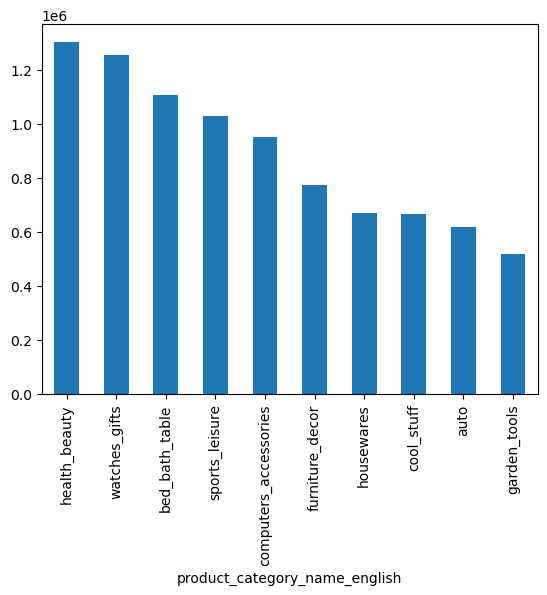

In [106]:
top10.plot(kind = "bar")

Text(0.5, 1.0, 'Top 10 product Categories by Revenue')

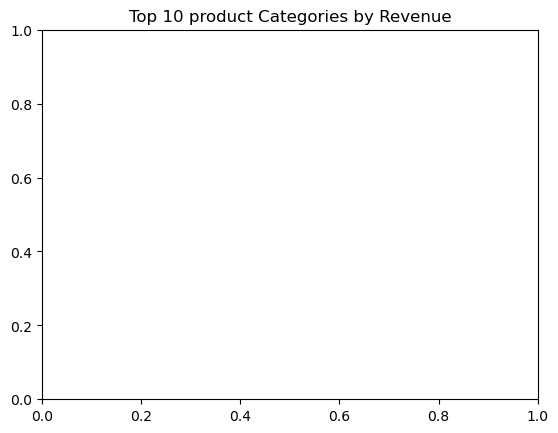

In [107]:
plt.title("Top 10 product Categories by Revenue")

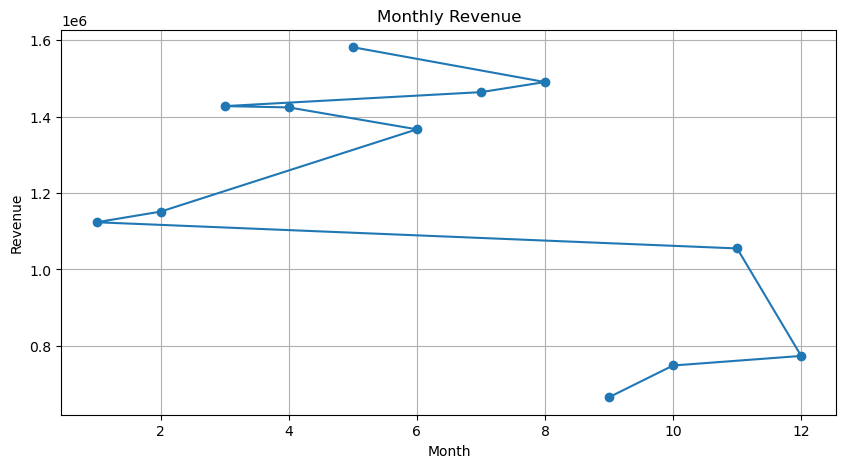

In [108]:
plt.figure(figsize = (10, 5))

monthly_revenue.plot(kind = "line", marker = "o")

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

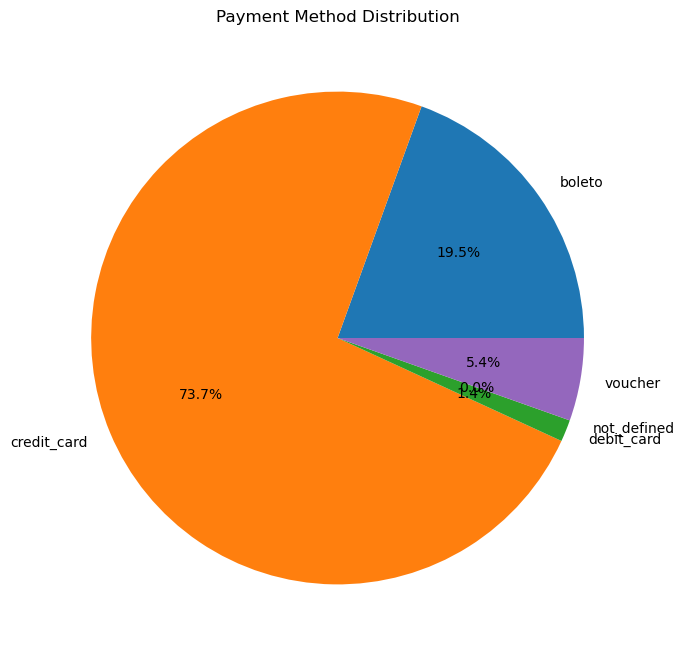

In [110]:
payment_distribution = (
    master_df
    .groupby("payment_type")
    .size()
)

plt.figure(figsize = (8,8))

payment_distribution.plot(
    kind = "pie",
    autopct = "%1.1f%%"
)

plt.title("Payment Method Distribution")

plt.ylabel("")

plt.show()

In [111]:
print(top10)

product_category_name_english
health_beauty            1301947.97
watches_gifts            1254322.95
bed_bath_table           1107249.09
sports_leisure           1029603.88
computers_accessories     950053.69
furniture_decor           772096.17
housewares                668880.94
cool_stuff                664637.13
auto                      618395.50
garden_tools              519473.33
Name: price, dtype: float64


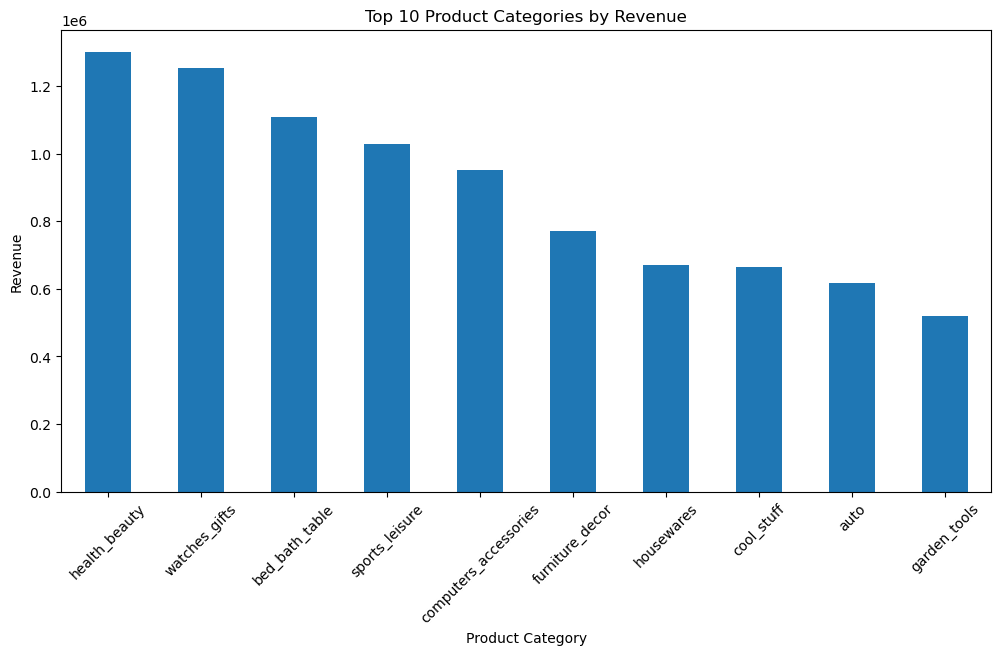

In [112]:
plt.figure(figsize = (12, 6))

top10.plot(kind = "bar")

plt.title("Top 10 Product Categories by Revenue")

plt.xlabel("Product Category")

plt.ylabel("Revenue")

plt.xticks(rotation = 45)

plt.show()

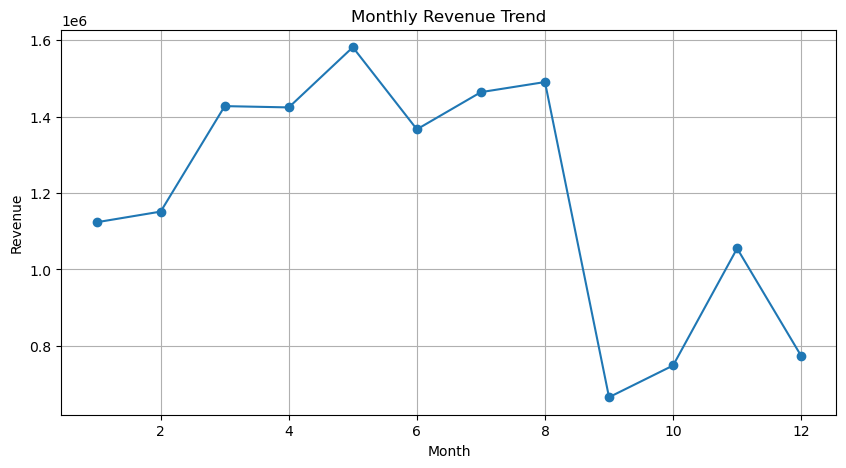

In [115]:
plt.figure(figsize = (10,5))

monthly_revenue.plot(
    kind = "line",
    marker = "o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

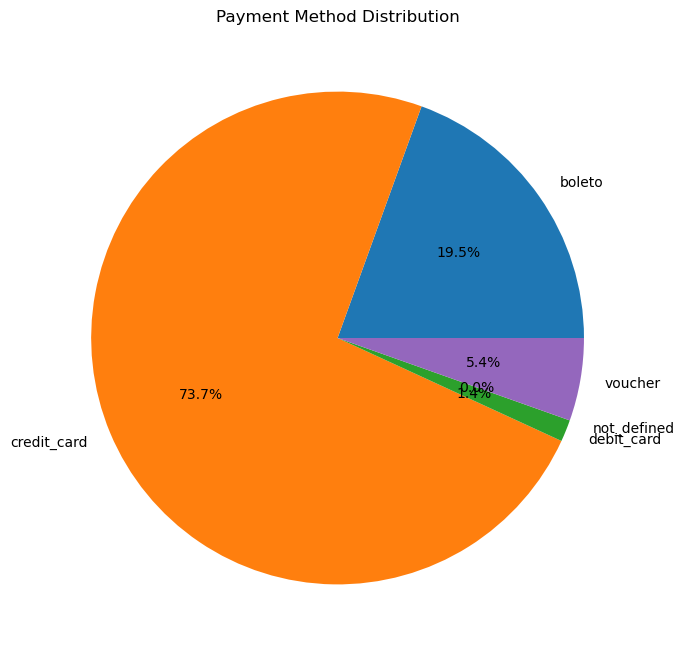

In [116]:
import matplotlib.pyplot as plt
payment_distribution = (
    master_df
    .groupby("payment_type")
    .size()
)
plt.figure(figsize = (8,8))

payment_distribution.plot(
    kind = "pie",
    autopct = "%1.1f%%"
)

plt.title("Payment Method Distribution")

plt.ylabel("")
plt.show()

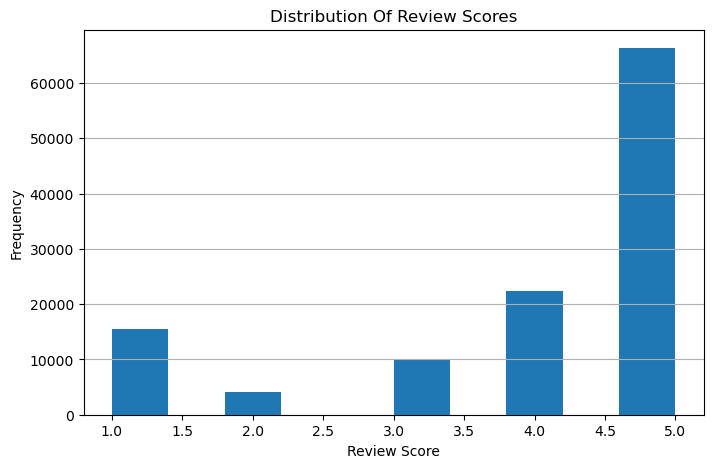

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))

master_df["review_score"].plot(kind="hist")

plt.title("Distribution Of Review Scores")

plt.xlabel("Review Score")

plt.ylabel("Frequency")
plt.grid(axis = "y")

plt.show()

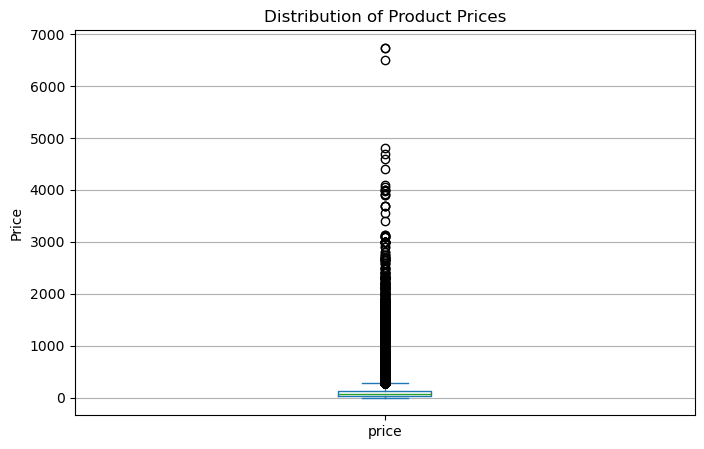

In [118]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))

master_df["price"].plot(kind = "box")

plt.title("Distribution of Product Prices")

plt.ylabel("Price")
plt.grid(axis = "y")
plt.show()

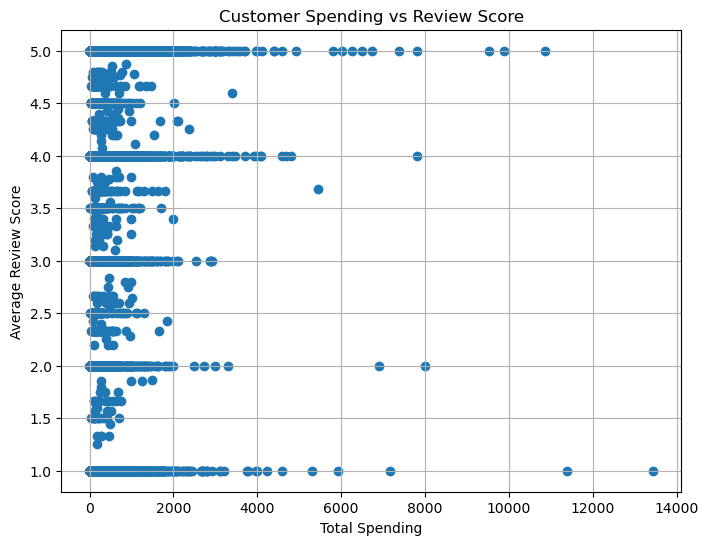

In [119]:
customer_analysis = (
    master_df
    .groupby("customer_unique_id")
    .agg({
        "price": "sum",
        "review_score" : "mean"
    })
    
)

plt.figure(figsize = (8,6))

plt.scatter(
    customer_analysis["price"],
    customer_analysis["review_score"]
)

plt.title("Customer Spending vs Review Score")

plt.xlabel("Total Spending")

plt.ylabel("Average Review Score")

plt.grid(True)

plt.show()